# USLR Preprocessing Tutorial

This notebook walks through the **preprocessing** step (`scripts/preprocess.py`) interactively, using the single subject included in `data/data_tutorial`.

The preprocessing pipeline has **two sequential sub-steps**:

| Step | Class | What it produces |
|------|-------|------------------|
| 1. SynthSeg segmentation | `USLRSegment` | `*T1wdseg.nii.gz` — whole-brain parcellation; `*T1wdseg.tsv` — structure volumes |
| 2. Bias field correction | `USLRBiasCorrection` | `*T1w.nii.gz` — inhomogeneity-corrected, WM-normalised image; `*T1wmask.nii.gz` — brain mask |

All outputs land under `derivatives/preproc/` and are the **required inputs** for the linear registration step.

### External dependency
Step 1 calls **`mri_synthseg`**, the command-line tool shipped with FreeSurfer ≥ 7.3 / the standalone SynthSeg distribution.  
A cell below checks whether it is available on your `PATH`.

## 1  Environment setup

Must be the **first** executed cell.

In [1]:
import os
import sys

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath('..')           # nicgiprep/
BIDS_DIR  = os.path.join(REPO_ROOT, 'data', 'data_tutorial', 'rawdata')

# ── Environment variables required by setup.py ─────────────────────────────
os.environ['PYTHONPATH']   = REPO_ROOT
os.environ['BIDS_DIR']     = BIDS_DIR
os.environ['USLR_RUNNING'] = 'True'         # suppresses the interactive FreeSurfer banner
os.environ['FREESURFER_HOME'] = '/home/acasamitjana/Software/freesurfer/freesurfer-supersynth/'

# ── sys.path ───────────────────────────────────────────────────────────────
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'scripts')]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'REPO_ROOT : {REPO_ROOT}')
print(f'BIDS_DIR  : {BIDS_DIR}')
print(f'BIDS_DIR exists: {os.path.exists(BIDS_DIR)}')

REPO_ROOT : /home/acasamitjana/Repositories/nicgiprep
BIDS_DIR  : /home/acasamitjana/Repositories/nicgiprep/data/data_tutorial/rawdata
BIDS_DIR exists: True


## 2  Imports

In [2]:
import shutil
import subprocess
from os.path import exists, join, dirname, basename

import bids
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from setup import *
from nicgiprep.utils import io_utils
from nicgiprep.pipelines import SynthSegProcessor, BiasCorrectionProcessor


/home/acasamitjana/Repositories/nicgiprep/nicgiprep/pipelines/base.py:153: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  subjects = list(filter(lambda s: len(self._get_data(**{'subject': s, **self.seg_entities},
E0000 00:00:1780567183.175554  145842 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780567183.186531  145842 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 3  Load the BIDS dataset

In [3]:
db_file = join(dirname(BIDS_DIR), 'BIDS-raw.db')

if not exists(db_file):
    print('Building BIDS index (first run) ...')
    bids_loader = bids.layout.BIDSLayout(root=BIDS_DIR, validate=False)
    bids_loader.save(db_file)
else:
    bids_loader = bids.layout.BIDSLayout(root=BIDS_DIR, validate=False, database_path=db_file)

bids_loader.add_derivatives(DIR_PIPELINES['preproc'])

subjects = bids_loader.get_subjects()
print(f'Subjects  : {subjects}')
print(f'Preproc → : {DIR_PIPELINES["preproc"]}')

Subjects  : ['ADNI002S1155']
Preproc → : /home/acasamitjana/Repositories/nicgiprep/data/data_tutorial/derivatives/preproc


## 4  Explore the raw T1w data

`USLRSegment._select_image()` picks **one** T1w per session according to these rules (in order):
1. Prefer files with no `acquisition` entity (or `acq-orig`) over other acquisitions.
2. If multiple runs exist, prefer `run-01`.

The cell below reproduces that selection and shows which file will be fed to SynthSeg.

In [4]:
SUBJECT = subjects[0]
sessions_all = bids_loader.get_session(subject=SUBJECT)
print(f'Subject  : sub-{SUBJECT}')
print(f'Sessions : {sessions_all}\n')

# Reproduce _select_image logic
rows = []
for tp in sessions_all:
    t1w_list = bids_loader.get(
        subject=SUBJECT, session=tp,
        extension=['nii', 'nii.gz'], suffix='T1w',
        acquisition=['orig', None], scope='raw'
    )
    if not t1w_list:
        rows.append({'session': tp, 'selected': '—  (no T1w)', 'all_files': ''})
        continue

    if len(t1w_list) > 1:
        no_acq = [f for f in t1w_list if 'acquisition' not in f.entities]
        run01  = [f for f in t1w_list if f.entities.get('run') == '01']
        chosen = (no_acq or run01 or t1w_list)[0]
    else:
        chosen = t1w_list[0]

    rows.append({
        'session':    tp,
        'selected':   chosen.filename,
        'all_files':  ', '.join(f.filename for f in t1w_list),
    })

df_raw = pd.DataFrame(rows)
display(df_raw)

Subject  : sub-ADNI002S1155
Sessions : ['m000', 'm006', 'm012', 'm018', 'm024', 'm048', 'm060', 'm072', 'm084', 'm096', 'm126', 'm138', 'm150']



,session,selected,all_files
0,m000,sub-ADNI002S1155_ses-m000_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m000_run-01_T1w.nii.gz, s..."
1,m006,sub-ADNI002S1155_ses-m006_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m006_run-01_T1w.nii.gz, s..."
2,m012,sub-ADNI002S1155_ses-m012_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m012_run-01_T1w.nii.gz, s..."
3,m018,sub-ADNI002S1155_ses-m018_run-02_T1w.nii.gz,sub-ADNI002S1155_ses-m018_run-02_T1w.nii.gz
4,m024,sub-ADNI002S1155_ses-m024_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m024_run-01_T1w.nii.gz, s..."
5,m048,sub-ADNI002S1155_ses-m048_run-02_T1w.nii.gz,"sub-ADNI002S1155_ses-m048_run-02_T1w.nii.gz, s..."
6,m060,sub-ADNI002S1155_ses-m060_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m060_run-01_T1w.nii.gz, s..."
7,m072,sub-ADNI002S1155_ses-m072_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m072_run-01_T1w.nii.gz, s..."
8,m084,sub-ADNI002S1155_ses-m084_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m084_run-01_T1w.nii.gz, s..."
9,m096,sub-ADNI002S1155_ses-m096_run-01_T1w.nii.gz,"sub-ADNI002S1155_ses-m096_run-01_T1w.nii.gz, s..."


Quick look at one raw image:

In [5]:
sample_row = df_raw[df_raw['selected'] != '—  (no T1w)'].iloc[0]
sample_ses = sample_row['session']
basename(sample_row['selected'])
io_utils.get_bids_entities(sample_row['selected'])

{'suffix': 'T1w',
 'subject': 'ADNI002S1155',
 'session': 'm000',
 'run': '01',
 'extension': 'nii.gz'}

Session   : ses-m000
File      : sub-ADNI002S1155_ses-m000_run-01_T1w.nii.gz
Shape     : (166, 256, 256)
Vox size  : [1.2   0.938 0.938] mm
Intensity : min=0  max=18108  mean=1093.3


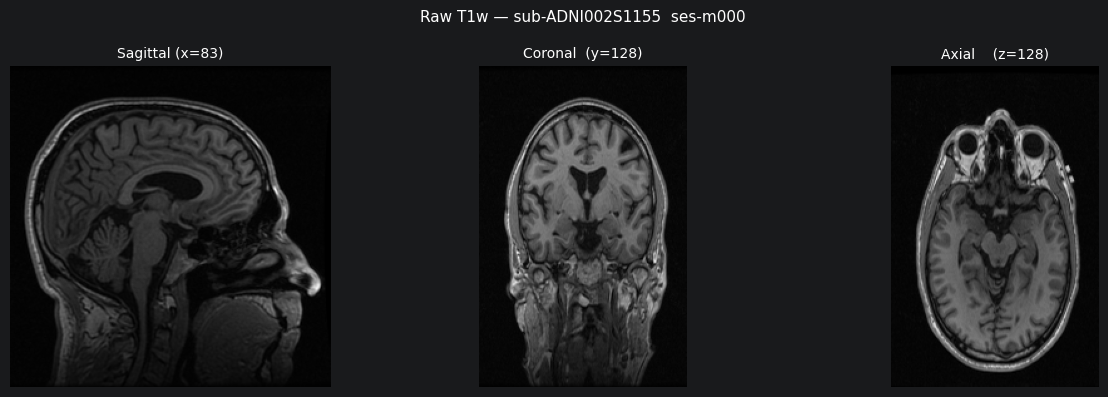

In [6]:
# Pick a session with a T1w to preview
sample_row = df_raw[df_raw['selected'] != '—  (no T1w)'].iloc[0]
sample_ses = sample_row['session']
sample_ent = io_utils.get_bids_entities(sample_row['selected'])
sample_file = bids_loader.get(scope='raw', **sample_ent)[0].path

proxy_raw = nib.load(sample_file)
vol_raw   = np.asarray(proxy_raw.dataobj)
print(f'Session   : ses-{sample_ses}')
print(f'File      : {basename(sample_file)}')
print(f'Shape     : {vol_raw.shape}')
print(f'Vox size  : {np.round(np.linalg.norm(proxy_raw.affine[:3, :3], axis=0), 3)} mm')
print(f'Intensity : min={vol_raw.min():.0f}  max={vol_raw.max():.0f}  mean={vol_raw.mean():.1f}')

cx, cy, cz = [s // 2 for s in vol_raw.shape]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (plane, title) in zip(axes, [
        (vol_raw[cx, :, :], f'Sagittal (x={cx})'),
        (vol_raw[:, cy, :], f'Coronal  (y={cy})'),
        (vol_raw[:, :, cz], f'Axial    (z={cz})'),
]):
    ax.imshow(np.rot90(plane), cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
fig.suptitle(f'Raw T1w — sub-{SUBJECT}  ses-{sample_ses}', fontsize=11)
plt.tight_layout()
plt.show()

## 5  Step 1 — SynthSeg segmentation (`USLRSegment`)

### 5.1  Check `mri_synthseg` availability

In [7]:
synthseg_available = shutil.which('mri_synthseg') is not None

if synthseg_available:
    result = subprocess.run(['mri_synthseg', '--version'], capture_output=True, text=True)
    print(f'✓  mri_synthseg found: {shutil.which("mri_synthseg")}')
    if result.stdout:
        print(f'   {result.stdout.strip()}')
else:
    print('✗  mri_synthseg not found on PATH.')
    print('   Source FreeSurfer ≥ 7.3 before running Step 1:')
    print('     source $FREESURFER_HOME/SetUpFreeSurfer.sh')
    print()
    print('   The USLRSegment cell below will still build and display the file lists')
    print('   but the actual segmentation call will be skipped.')

✓  mri_synthseg found: /home/acasamitjana/Software/freesurfer/freesurfer-stable/bin/mri_synthseg


### 5.2  Initialise `USLRSegment` and inspect the planned file lists

`USLRSegment.process()` first gathers three parallel lists — input T1w paths, 1 mm resampled paths, and segmentation output paths — then passes them all at once to `mri_synthseg` for batched inference.

In [8]:
processing_seg = SynthSegProcessor(bids_loader=bids_loader, subject_list=[SUBJECT])

# Dry-run: call process_subject to see what would be queued (without force_flag=True
# existing outputs are skipped automatically)
input_files, res_files, out_files, vol_files, _ = processing_seg.process_subject(
    SUBJECT, force_flag=False
)

print(f'Sessions queued for SynthSeg: {len(input_files)}')
rows = []
for inp, out in zip(input_files, out_files):
    rows.append({
        'input T1w':    basename(inp),
        'seg output':   basename(out),
        'output exists': '✓' if exists(out) else '✗',
    })
if rows:
    display(pd.DataFrame(rows))
else:
    print('All sessions already have segmentation outputs.')

Sessions queued for SynthSeg: 0
All sessions already have segmentation outputs.


### 5.3  Run SynthSeg segmentation

Internally calls:
```
mri_synthseg --i <input_list.txt> --o <output_list.txt> \
             --resample <resample_list.txt> --vol <vol_list.txt> \
             --threads 16 --robust --parc --cpu
```

In [9]:
processing_seg.process(force_flag=False)

### 5.4  Inspect segmentation outputs

For each session we get:
- `*T1wdseg.nii.gz` — integer label map (SynthSeg/FreeSurfer label space)
- `*T1wdseg.tsv` — structure volumes in mm³
- `*T1w.nii.gz` — T1w resampled to 1 mm isotropic (used for bias correction)

In [10]:
# Need to update the layout (just in case)
processing_seg._update_full_layout()

seg_entities = {'scope': 'preproc', 'extension': 'nii.gz', 'suffix': ['T1wdseg', 'dseg']}
seg_files = processing_seg.bids_loader.get(subject=SUBJECT, **seg_entities)
print(f'Segmentation files found: {len(seg_files)}')
for f in seg_files:
    proxy = nib.load(f.path)
    labels = np.unique(np.asarray(proxy.dataobj))
    print(f'  ses-{f.entities["session"]:8s}  shape={proxy.shape}  labels={len(labels)}')

Segmentation files found: 13
  ses-m000      shape=(200, 240, 240)  labels=99
  ses-m006      shape=(200, 240, 240)  labels=99
  ses-m012      shape=(200, 240, 240)  labels=99
  ses-m018      shape=(200, 240, 240)  labels=99
  ses-m024      shape=(200, 240, 240)  labels=99
  ses-m048      shape=(201, 240, 240)  labels=99
  ses-m060      shape=(204, 256, 256)  labels=99
  ses-m072      shape=(204, 256, 256)  labels=99
  ses-m084      shape=(204, 256, 256)  labels=99
  ses-m096      shape=(205, 256, 256)  labels=99
  ses-m126      shape=(212, 254, 270)  labels=99
  ses-m138      shape=(208, 240, 256)  labels=99
  ses-m150      shape=(208, 240, 256)  labels=99


In [11]:
# Volume table for one session
tsv_files_seg = processing_seg.bids_loader.get(subject=SUBJECT, scope='preproc', suffix=['T1wdseg', 'dseg'], extension='tsv')
if tsv_files_seg:
    df_vols = pd.read_csv(tsv_files_seg[0].path, sep=',')
    print(f'Volume table for ses-{tsv_files_seg[0].entities["session"]} ({tsv_files_seg[0].filename}):')
    display(df_vols.T.head(20))

Volume table for ses-m000 (sub-ADNI002S1155_ses-m000_acq-1_run-01_T1wdseg.tsv):


,0
Unnamed: 0,sub-ADNI002S1155_ses-m000_run-01_T1w
total intracranial,1561328.5
left cerebral white matter,245821.69
left cerebral cortex,272848.97
left lateral ventricle,19425.803
left inferior lateral ventricle,647.696
left cerebellum white matter,14582.443
left cerebellum cortex,56810.883
left thalamus,6923.544
left caudate,3853.852


### 5.5  Visualise: T1w + segmentation overlay

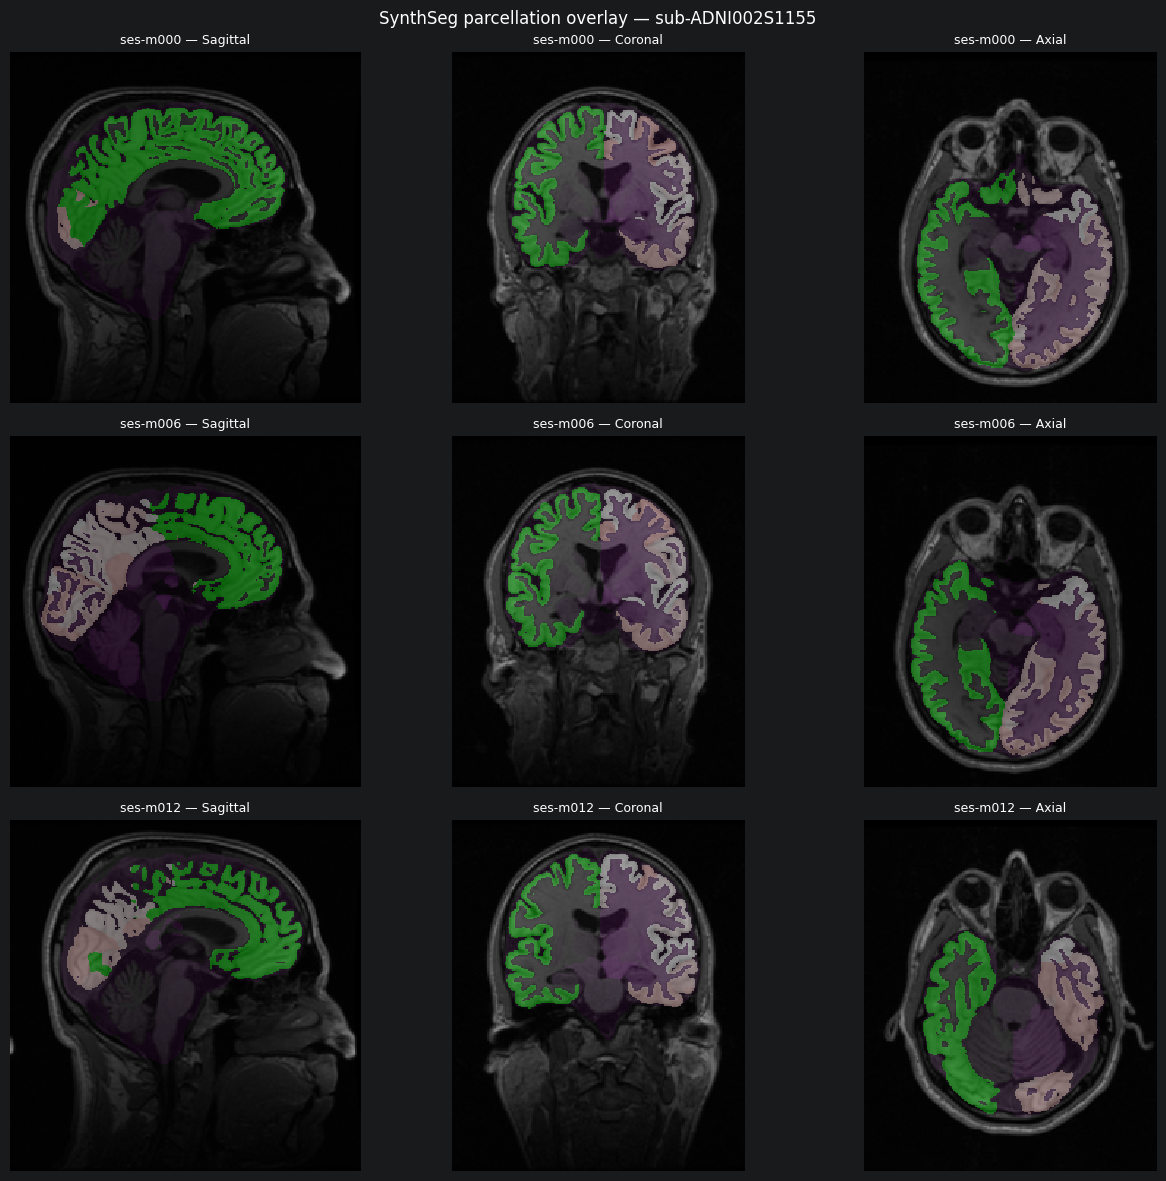

In [12]:
if seg_files:
    # Show up to 3 sessions
    show = seg_files[:3]
    fig, axes = plt.subplots(len(show), 3, figsize=(13, 4 * len(show)))
    if len(show) == 1:
        axes = axes[np.newaxis, :]

    for row_idx, seg_f in enumerate(show):
        tp = seg_f.entities['session']
        proxy_seg = nib.load(seg_f.path)
        seg_vol   = np.asarray(proxy_seg.dataobj)

        # Load corresponding resampled T1w (acq-1)
        t1w_f = bids_loader.get(subject=SUBJECT, session=tp, scope='preproc',
                                suffix='T1w', acquisition='1', extension='nii.gz')
        if t1w_f:
            t1w_vol = np.asarray(nib.load(t1w_f[0].path).dataobj).astype(float)
        else:
            t1w_vol = np.zeros_like(seg_vol, dtype=float)

        cx, cy, cz = [s // 2 for s in seg_vol.shape]
        for col_idx, (t1_plane, seg_plane, title) in enumerate([
            (t1w_vol[cx, :, :], seg_vol[cx, :, :], f'Sagittal'),
            (t1w_vol[:, cy, :], seg_vol[:, cy, :], f'Coronal'),
            (t1w_vol[:, :, cz], seg_vol[:, :, cz], f'Axial'),
        ]):
            ax = axes[row_idx, col_idx]
            ax.imshow(np.rot90(t1_plane), cmap='gray', interpolation='nearest')
            ax.imshow(np.rot90(seg_plane.astype(float)), cmap='nipy_spectral',
                      alpha=0.45, interpolation='nearest', vmin=0, vmax=seg_vol.max())
            ax.set_title(f'ses-{tp} — {title}', fontsize=9)
            ax.axis('off')

    fig.suptitle(f'SynthSeg parcellation overlay — sub-{SUBJECT}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 6  Step 2 — Bias field correction (`USLRBiasCorrection`)

For each session this step:
1. Derives a **brain mask** from the SynthSeg labels (excludes CSF, label 24).
2. Computes a smooth **multiplicative bias field** via EM fitting of a DCT basis on the log-intensity image, guided by the soft segmentation.
3. Divides the image by the bias field and **normalises** so that the white-matter mean = 110.
4. Applies a dilated brain mask and clips to `[0, 255]`, saving as `uint8`.

### 6.1  Initialise and run

In [13]:
processing_bias = BiasCorrectionProcessor(bids_loader=processing_seg.bids_loader, subject_list=[SUBJECT])
processing_bias.process(force_flag=False)


Subject: ADNI002S1155

* Session: m000: image already processed.

* Session: m006: image already processed.

* Session: m012: image already processed.

* Session: m018: image already processed.

* Session: m024: image already processed.

* Session: m048: image already processed.

* Session: m060: image already processed.

* Session: m072: image already processed.

* Session: m084: image already processed.

* Session: m096: image already processed.

* Session: m126: image already processed.

* Session: m138: image already processed.

* Session: m150: image already processed.
Subjects that failed: 
ADNI002S1155


### 6.2  Inspect outputs

In [14]:
# Reload layout
bids_loader = bids.layout.BIDSLayout(root=BIDS_DIR, validate=False, database_path=db_file)
bids_loader.add_derivatives(DIR_PIPELINES['preproc'])

bf_entities   = {'scope': 'preproc', 'extension': 'nii.gz', 'suffix': 'T1w',
                 'acquisition': [None, 'orig']}
mask_entities = {'scope': 'preproc', 'extension': 'nii.gz', 'suffix': 'T1wmask'}

bf_files   = bids_loader.get(subject=SUBJECT, **bf_entities)
mask_files = bids_loader.get(subject=SUBJECT, **mask_entities)

print(f'Bias-corrected T1w files : {len(bf_files)}')
print(f'Brain mask files         : {len(mask_files)}')

rows = []
for f in bf_files:
    proxy = nib.load(f.path)
    v = np.asarray(proxy.dataobj)
    rows.append({
        'session': f.entities.get('session', '—'),
        'shape':   str(proxy.shape),
        'dtype':   str(v.dtype),
        'min':     int(v.min()),
        'max':     int(v.max()),
        'mean':    round(float(v[v > 0].mean()), 1) if v.max() > 0 else 0,
    })
display(pd.DataFrame(rows))

Bias-corrected T1w files : 13
Brain mask files         : 13


,session,shape,dtype,min,max,mean
0,m000,"(166, 256, 256)",uint8,0,255,76.6
1,m006,"(166, 256, 256)",uint8,0,255,76.5
2,m012,"(166, 256, 256)",uint8,0,255,77.0
3,m018,"(166, 256, 256)",uint8,0,255,76.9
4,m024,"(166, 256, 256)",uint8,0,255,76.4
5,m048,"(166, 256, 256)",uint8,0,255,76.5
6,m060,"(170, 256, 256)",uint8,0,255,74.3
7,m072,"(170, 256, 256)",uint8,0,255,75.0
8,m084,"(170, 256, 256)",uint8,0,255,74.3
9,m096,"(170, 256, 256)",uint8,0,255,73.5


### 6.3  Visualise: raw vs bias-corrected comparison

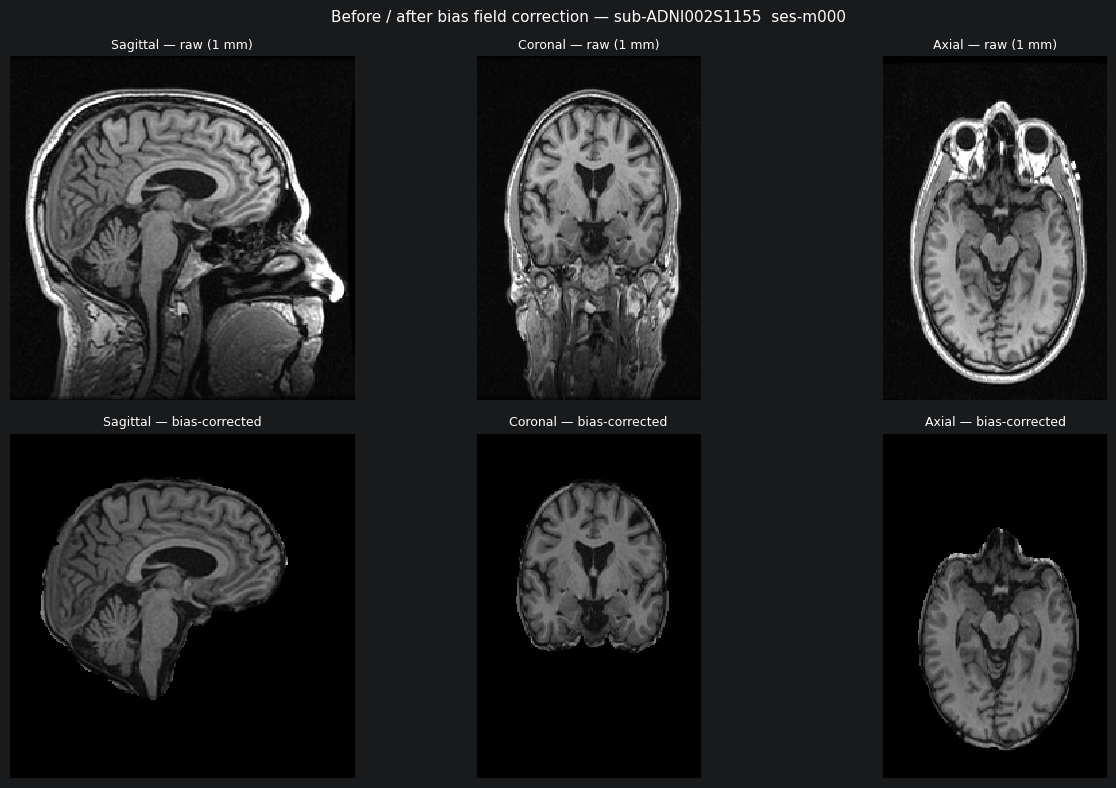

In [15]:
if bf_files:
    bf_f   = bf_files[0]
    tp_vis = bf_f.entities.get('session')

    # Raw T1w (resampled to 1 mm, stored as acq-1 by SynthSeg step)
    raw_f = bids_loader.get(subject=SUBJECT, session=tp_vis, scope='raw', suffix='T1w',  extension='nii.gz')

    vol_bf  = np.asarray(nib.load(bf_f.path).dataobj).astype(float)
    vol_raw = np.asarray(nib.load(raw_f[0].path).dataobj).astype(float) if raw_f else vol_bf

    cx, cy, cz = [s // 2 for s in vol_bf.shape]

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    views = [
        (vol_raw[cx,:,:], vol_bf[cx,:,:], 'Sagittal'),
        (vol_raw[:,cy,:], vol_bf[:,cy,:], 'Coronal'),
        (vol_raw[:,:,cz], vol_bf[:,:,cz], 'Axial'),
    ]
    vmax = np.percentile(vol_raw[vol_raw > 0], 99) if vol_raw.max() > 0 else 1

    for col, (raw_plane, bf_plane, title) in enumerate(views):
        axes[0, col].imshow(np.rot90(raw_plane), cmap='gray', vmin=0, vmax=vmax, interpolation='nearest')
        axes[0, col].set_title(f'{title} — raw (1 mm)', fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(np.rot90(bf_plane), cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        axes[1, col].set_title(f'{title} — bias-corrected', fontsize=9)
        axes[1, col].axis('off')

    fig.suptitle(f'Before / after bias field correction — sub-{SUBJECT}  ses-{tp_vis}', fontsize=11)
    plt.tight_layout()
    plt.show()

### 6.4  Intensity distribution: before vs after

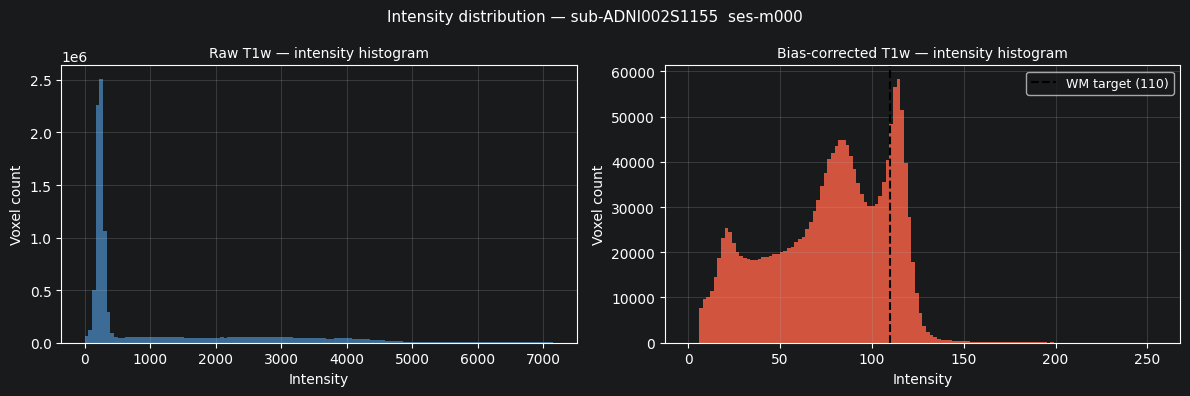

In [16]:
if raw_f and bf_files:
    raw_vals = vol_raw[vol_raw > 5].ravel()
    bf_vals  = vol_bf[vol_bf   > 5].ravel()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.hist(raw_vals, bins=128, color='steelblue', alpha=0.8, range=(0, np.percentile(raw_vals, 99.5)))
    ax1.set_title('Raw T1w — intensity histogram', fontsize=10)
    ax1.set_xlabel('Intensity')
    ax1.set_ylabel('Voxel count')
    ax1.grid(True, alpha=0.3)

    ax2.hist(bf_vals, bins=128, color='tomato', alpha=0.8, range=(0, 255))
    ax2.axvline(110, color='black', linestyle='--', linewidth=1.5, label='WM target (110)')
    ax2.set_title('Bias-corrected T1w — intensity histogram', fontsize=10)
    ax2.set_xlabel('Intensity')
    ax2.set_ylabel('Voxel count')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'Intensity distribution — sub-{SUBJECT}  ses-{tp_vis}', fontsize=11)
    plt.tight_layout()
    plt.show()

## 7  Summary across all sessions

In [17]:
seg_entities_check  = {'scope': 'preproc', 'extension': 'nii.gz', 'suffix': ['T1wdseg', 'dseg']}
bf_entities_check   = {'scope': 'preproc', 'extension': 'nii.gz', 'suffix': 'T1w', 'acquisition': [None, 'orig']}
mask_entities_check = {'scope': 'preproc', 'extension': 'nii.gz', 'suffix': 'T1wmask'}

rows = []
for ses in sessions_all:
    seg  = bids_loader.get(subject=SUBJECT, session=ses, **seg_entities_check)
    bf   = bids_loader.get(subject=SUBJECT, session=ses, **bf_entities_check)
    mask = bids_loader.get(subject=SUBJECT, session=ses, **mask_entities_check)
    rows.append({
        'session':     ses,
        'segmentation': '✓' if seg  else '✗',
        'bias-corr T1w': '✓' if bf   else '✗',
        'brain mask':    '✓' if mask else '✗',
    })

df_summary = pd.DataFrame(rows).set_index('session')
ready = (df_summary == '✓').all(axis=1).sum()
print(f'{ready}/{len(sessions_all)} sessions fully preprocessed.')
display(df_summary)

13/13 sessions fully preprocessed.


,segmentation,bias-corr T1w,brain mask
session,,,
m000,✓,✓,✓
m006,✓,✓,✓
m012,✓,✓,✓
m018,✓,✓,✓
m024,✓,✓,✓
m048,✓,✓,✓
m060,✓,✓,✓
m072,✓,✓,✓
m084,✓,✓,✓


## 8  Output directory structure

In [18]:
result = subprocess.run(
    ['find', DIR_PIPELINES['preproc'], '-name', '*.nii.gz', '-o', '-name', '*.tsv'],
    capture_output=True, text=True
)
lines = sorted(result.stdout.strip().split('\n'))
print(f'Files in {DIR_PIPELINES["preproc"]}:')
for l in lines:
    if l:
        print(' ', l.replace(DIR_PIPELINES['preproc'] + '/', ''))

Files in /home/acasamitjana/Repositories/nicgiprep/data/data_tutorial/derivatives/preproc:
  sub-ADNI002S1155/ses-m000/anat/sub-ADNI002S1155_ses-m000_acq-1_run-01_T1w.nii.gz
  sub-ADNI002S1155/ses-m000/anat/sub-ADNI002S1155_ses-m000_acq-1_run-01_T1wdseg.nii.gz
  sub-ADNI002S1155/ses-m000/anat/sub-ADNI002S1155_ses-m000_acq-1_run-01_T1wdseg.tsv
  sub-ADNI002S1155/ses-m000/anat/sub-ADNI002S1155_ses-m000_acq-1_run-01_T1wmask.nii.gz
  sub-ADNI002S1155/ses-m000/anat/sub-ADNI002S1155_ses-m000_run-01_T1w.nii.gz
  sub-ADNI002S1155/ses-m006/anat/sub-ADNI002S1155_ses-m006_acq-1_run-01_T1w.nii.gz
  sub-ADNI002S1155/ses-m006/anat/sub-ADNI002S1155_ses-m006_acq-1_run-01_T1wdseg.nii.gz
  sub-ADNI002S1155/ses-m006/anat/sub-ADNI002S1155_ses-m006_acq-1_run-01_T1wdseg.tsv
  sub-ADNI002S1155/ses-m006/anat/sub-ADNI002S1155_ses-m006_acq-1_run-01_T1wmask.nii.gz
  sub-ADNI002S1155/ses-m006/anat/sub-ADNI002S1155_ses-m006_run-01_T1w.nii.gz
  sub-ADNI002S1155/ses-m012/anat/sub-ADNI002S1155_ses-m012_acq-1_run-01_T

---
Once all sessions show `✓` in the summary table, you can proceed to the **linear registration** tutorial (`linear_registration_tutorial.ipynb`).